###### Financial Econometrics I

#### High-frequency financial models - Microstructure noise.

by František Čech, based on previous years' materials prepared by Jozef Baruník and Josef Kurka

#### Seminar 7: Summer Semester 2025/2026
___

In [1]:
library(repr)
options(repr.plot.width = 12, repr.plot.height = 6)

library(xts)
library(quantmod)

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


Loading required package: TTR

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



## Roll's model

Simulate Roll's model of prices which takes the form

$$P_t = P_t^* + I_t \frac{S}{2}, $$
where $P_t^*$ is the fundamental value independent on S, $S = P_A - P_B$ is the bid ask spread.

$$ I_t = \begin{cases}
        1 & \text{with probability p} = 0.5 \\
        -1 & \text{with probability q} = 0.5.
        \end{cases}$$

In [2]:
days<-seq(from=as.Date("2010-01-01"),by ="day",length.out = 2000)
biz_days<-as.POSIXlt(days)$wday
biz_days[biz_days==6|biz_days==0]<- NA
biz_days<-as.Date(na.omit(cbind(days,biz_days))[,1],origin="1970-01-01")

In [3]:
head(biz_days,15)

[1] "2010-01-01" "2010-01-04" "2010-01-05" "2010-01-06" "2010-01-07"
 [6] "2010-01-08" "2010-01-11" "2010-01-12" "2010-01-13" "2010-01-14"
[11] "2010-01-15" "2010-01-18" "2010-01-19" "2010-01-20" "2010-01-21"

In [4]:
TT <- 1000
epsilon <- rnorm(TT)
I <- sample(c(-1, 1), size = TT, replace = TRUE)
Pstar <- vector()
Pstar[1] <- 100 + epsilon[1]

for (t in 2:TT){
  if ((Pstar[t - 1] + epsilon[t]) > 0){
    Pstar[t] <- Pstar[t - 1] + epsilon[t]
  }
  else {Pstar[t] <- 0}
}
Pstar<-xts(Pstar,order.by = as.Date(biz_days[1:TT]))

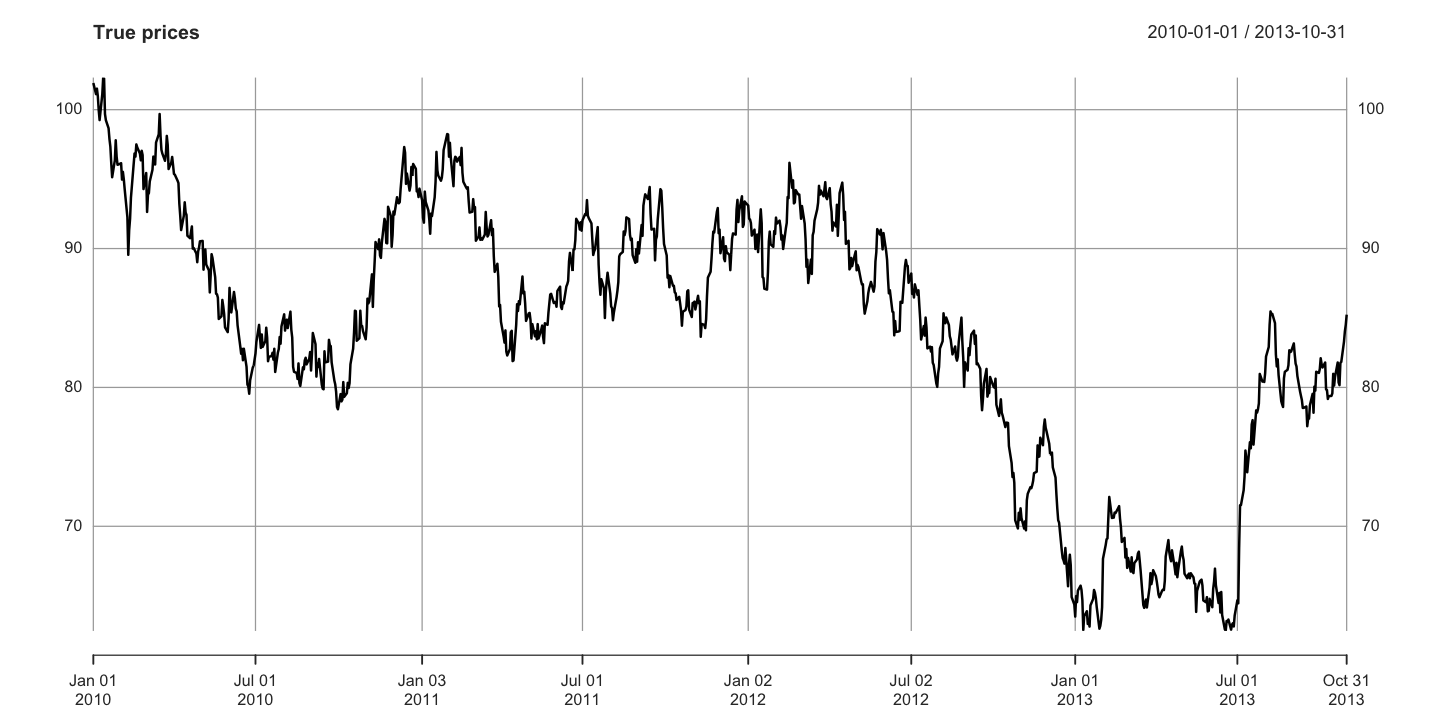

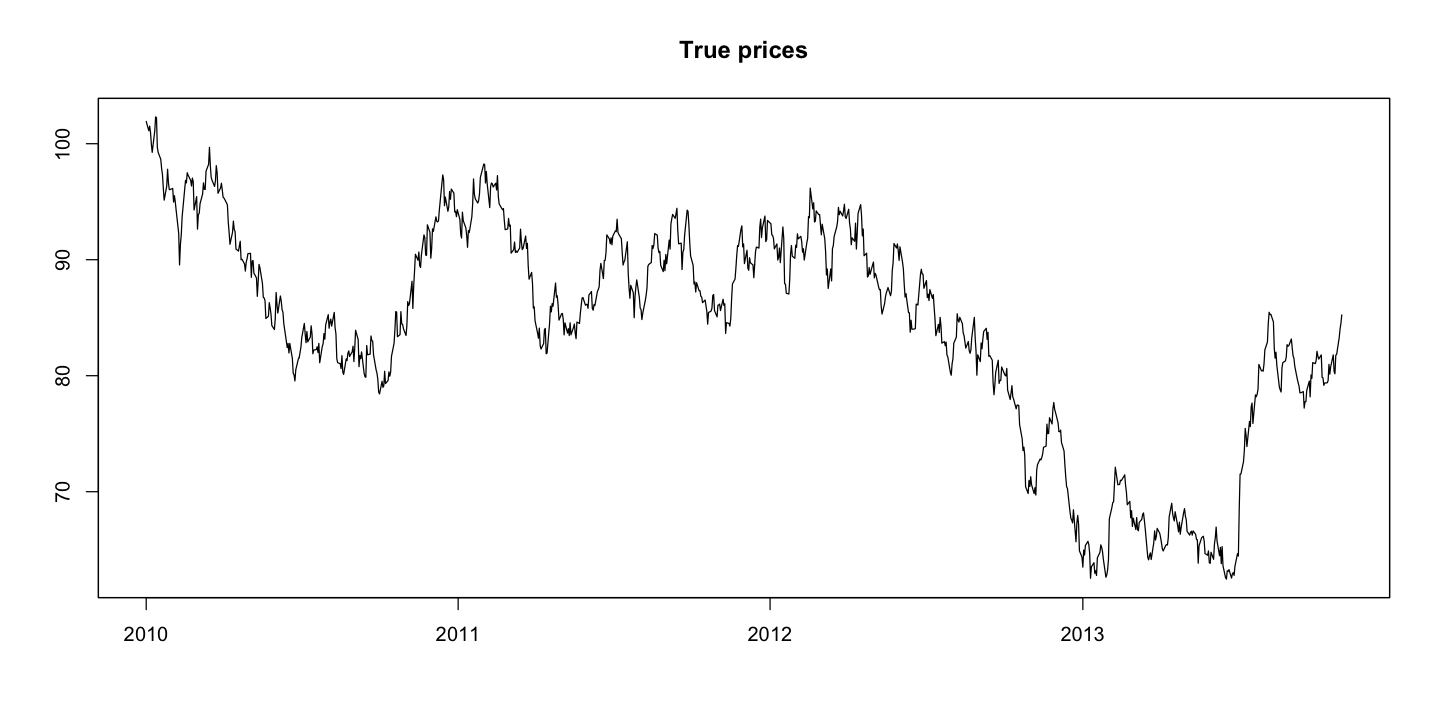

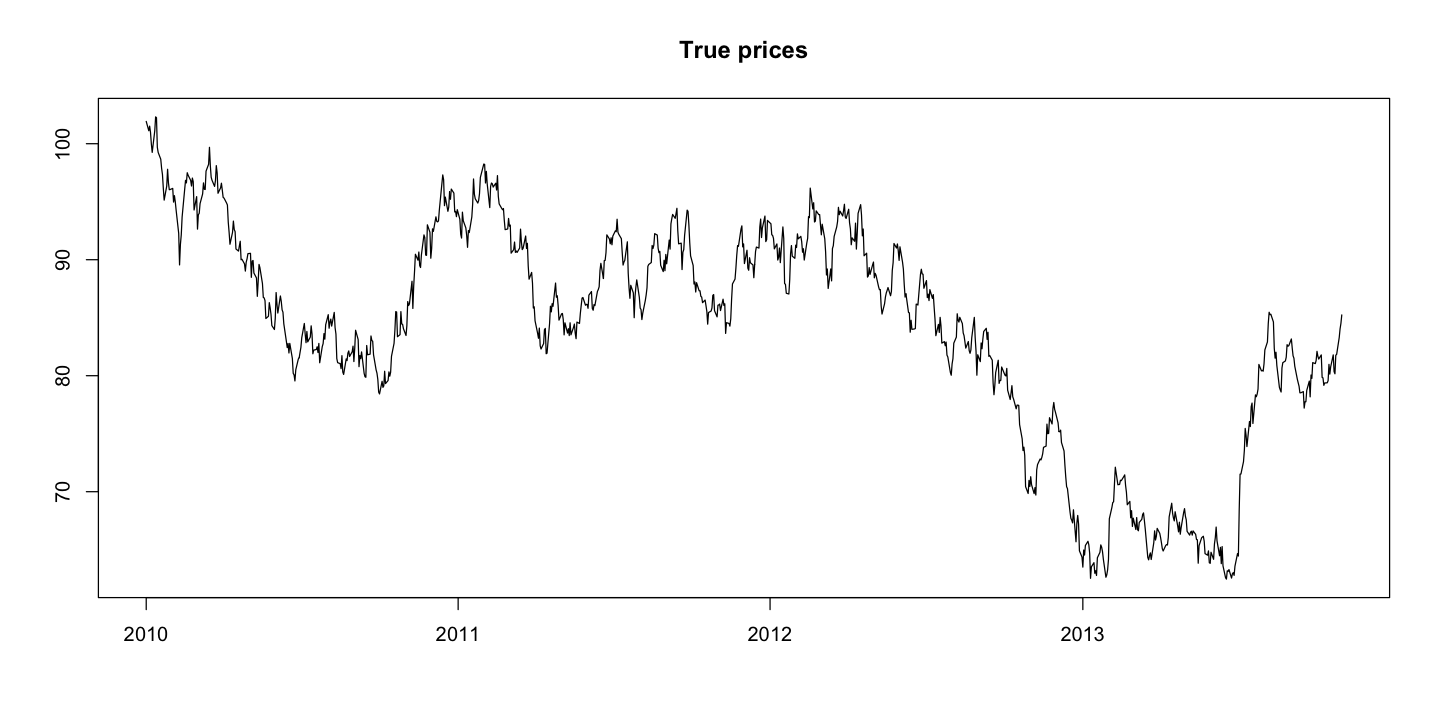

In [5]:
plot.xts(Pstar, main = 'True prices',ylab = NA,xlab = NA)
plot.zoo(Pstar, main = 'True prices',ylab = NA,xlab = NA)
plot(x=index(Pstar),y=Pstar,type="l",main = 'True prices',ylab = NA,xlab = NA)

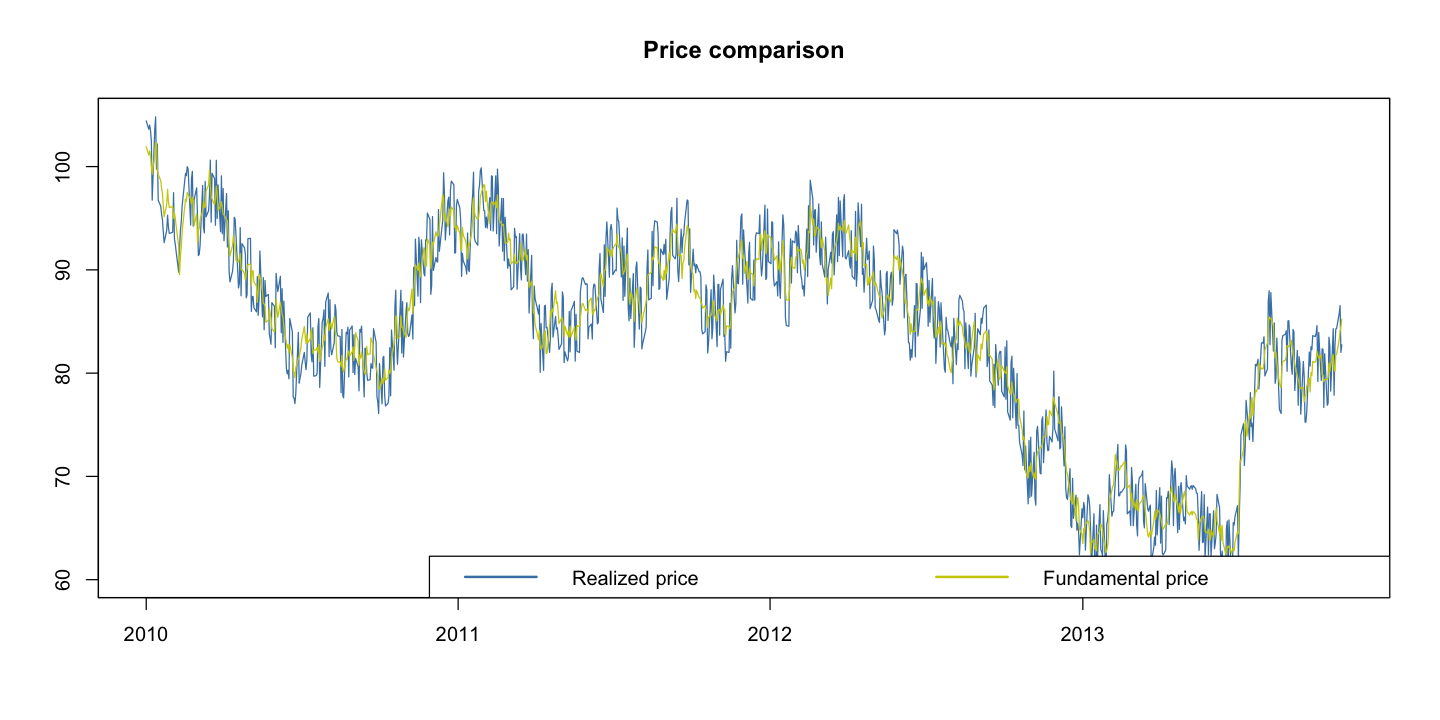

In [6]:
spread <- 5
P <- vector()
for (t in 1:TT){
  P[t] <- Pstar[t] + I[t] * spread / 2
}
P<-xts(P,order.by =as.Date(biz_days[1:TT]))

plot.zoo(P,xlab = NA, ylab = NA, main = 'Price comparison', col = 'steelblue')
lines(zoo(Pstar), col = 'yellow3')
legend("bottomright", ncol = 2, legend = c('Realized price', 'Fundamental price'),
       col = c('steelblue', 'yellow3'), lwd = 2)

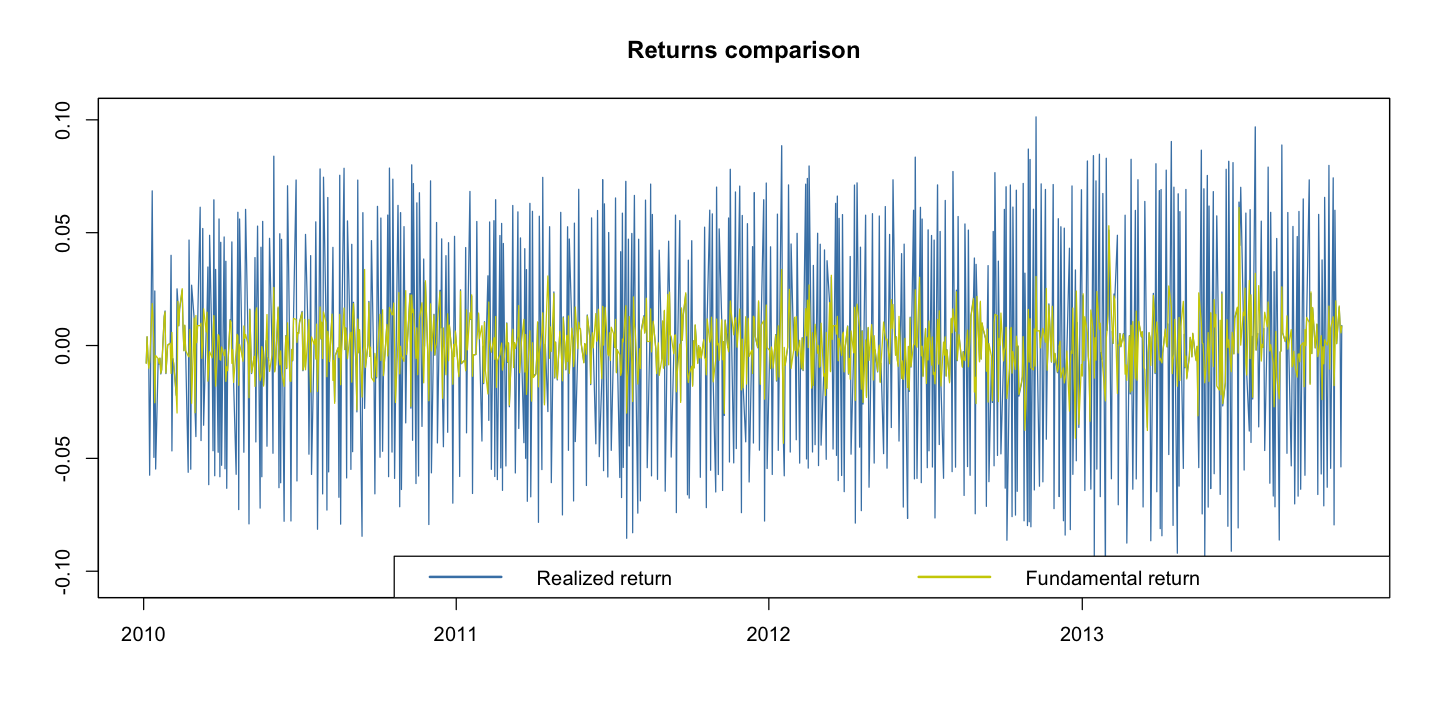

In [7]:
retstar <- na.omit(diff(log(Pstar)))
ret <- na.omit(diff(log(P)))

plot.zoo(ret,xlab = NA, ylab = NA, main = 'Returns comparison', col = 'steelblue')
lines(zoo(retstar), col = 'yellow3')
legend("bottomright", ncol = 2, legend = c('Realized return', 'Fundamental return'),
       col = c('steelblue', 'yellow3'), lwd = 2)


Both plots show the noise induced by presence of bid-ask spread. Moreover, it also influences $corr( \Delta p_t, \Delta p_{t-1})$. Note that this quantity should be zero, as the fundamental price process is modelled as White noise in our case.

In [8]:
cor(retstar[1:(TT - 2),1], retstar[2:(TT - 1),1])

-0.02209457


In [9]:
as.numeric(cor(ret[1:(TT - 2),1], ret[2:(TT - 1),1]))

[1] -0.4793224

## Continuous-time models in finance

## Jump difusion model

Simulate volatility using the continuous time GARCH.

$d p(t) = \sigma(t) d W_1(t)$

$d \sigma^2(t) = \theta_1 (\theta_2 - \sigma^2(t)) dt + \theta_3 \sigma^2(t) d W_2(t)$

with $p(t)$ being logarithm of prices $p(t) = \log S(t)$, hence $r(t) = p(t) - p(t-1)$, and $W_i$ being independent Brownian motions.

In [10]:
theta <- c(0.035, 0.636, 0.296) # S&P 500 calibrated
TT=500
NN=300
dt <- 1 / NN

time_sim<- seq(from=as.POSIXct("2010-01-01 9:30"),to=as.POSIXct("2010-01-01 15:59"),by="min")
hh_mm<- format(time_sim, format = "%H:%M:%S")
date_time<-unlist(lapply(1:TT, function(x) paste(rep(biz_days[x],300),sort(sample(hh_mm,NN,replace = FALSE)))))

In [11]:
head(date_time,301)

[1] "2010-01-01 09:30:00" "2010-01-01 09:31:00" "2010-01-01 09:32:00"
  [4] "2010-01-01 09:33:00" "2010-01-01 09:34:00" "2010-01-01 09:35:00"
  [7] "2010-01-01 09:37:00" "2010-01-01 09:38:00" "2010-01-01 09:39:00"
 [10] "2010-01-01 09:40:00" "2010-01-01 09:41:00" "2010-01-01 09:42:00"
 [13] "2010-01-01 09:43:00" "2010-01-01 09:44:00" "2010-01-01 09:45:00"
 [16] "2010-01-01 09:48:00" "2010-01-01 09:49:00" "2010-01-01 09:50:00"
 [19] "2010-01-01 09:52:00" "2010-01-01 09:55:00" "2010-01-01 09:56:00"
 [22] "2010-01-01 09:57:00" "2010-01-01 09:58:00" "2010-01-01 09:59:00"
 [25] "2010-01-01 10:00:00" "2010-01-01 10:01:00" "2010-01-01 10:03:00"
 [28] "2010-01-01 10:05:00" "2010-01-01 10:06:00" "2010-01-01 10:08:00"
 [31] "2010-01-01 10:10:00" "2010-01-01 10:11:00" "2010-01-01 10:12:00"
 [34] "2010-01-01 10:13:00" "2010-01-01 10:18:00" "2010-01-01 10:19:00"
 [37] "2010-01-01 10:20:00" "2010-01-01 10:21:00" "2010-01-01 10:22:00"
 [40] "2010-01-01 10:24:00" "2010-01-01 10:25:00" "2010-01-01 10:28:00"
 [43] "2010-01-01 10:29:00" "2010-01-01 10:30:00" "2010-01-01 10:31:00"
 [46] "2010-01-01 10:32:00" "2010-01-01 10:33:00" "2010-01-01 10:34:00"
 [49] "2010-01-01 10:35:00" "2010-01-01 10:36:00" "2010-01-01 10:37:00"
 [52] "2010-01-01 10:38:00" "2010-01-01 10:39:00" "2010-01-01 10:40:00"
 [55] "2010-01-01 10:43:00" "2010-01-01 10:46:00" "2010-01-01 10:48:00"
 [58] "2010-01-01 10:49:00" "2010-01-01 10:50:00" "2010-01-01 10:51:00"
 [61] "2010-01-01 10:52:00" "2010-01-01 10:54:00" "2010-01-01 10:55:00"
 [64] "2010-01-01 10:56:00" "2010-01-01 10:57:00" "2010-01-01 10:58:00"
 [67] "2010-01-01 10:59:00" "2010-01-01 11:00:00" "2010-01-01 11:01:00"
 [70] "2010-01-01 11:03:00" "2010-01-01 11:05:00" "2010-01-01 11:06:00"
 [73] "2010-01-01 11:07:00" "2010-01-01 11:08:00" "2010-01-01 11:10:00"
 [76] "2010-01-01 11:11:00" "2010-01-01 11:13:00" "2010-01-01 11:14:00"
 [79] "2010-01-01 11:16:00" "2010-01-01 11:17:00" "2010-01-01 11:18:00"
 [82] "2010-01-01 11:19:00" "2010-01-01 11:20:00" "2010-01-01 11:22:00"
 [85] "2010-01-01 11:23:00" "2010-01-01 11:24:00" "2010-01-01 11:25:00"
 [88] "2010-01-01 11:27:00" "2010-01-01 11:28:00" "2010-01-01 11:29:00"
 [91] "2010-01-01 11:30:00" "2010-01-01 11:31:00" "2010-01-01 11:32:00"
 [94] "2010-01-01 11:34:00" "2010-01-01 11:35:00" "2010-01-01 11:36:00"
 [97] "2010-01-01 11:37:00" "2010-01-01 11:39:00" "2010-01-01 11:41:00"
[100] "2010-01-01 11:42:00" "2010-01-01 11:45:00" "2010-01-01 11:46:00"
[103] "2010-01-01 11:48:00" "2010-01-01 11:49:00" "2010-01-01 11:51:00"
[106] "2010-01-01 11:53:00" "2010-01-01 11:54:00" "2010-01-01 11:55:00"
[109] "2010-01-01 11:56:00" "2010-01-01 11:58:00" "2010-01-01 11:59:00"
[112] "2010-01-01 12:00:00" "2010-01-01 12:01:00" "2010-01-01 12:02:00"
[115] "2010-01-01 12:03:00" "2010-01-01 12:04:00" "2010-01-01 12:06:00"
[118] "2010-01-01 12:07:00" "2010-01-01 12:09:00" "2010-01-01 12:10:00"
[121] "2010-01-01 12:12:00" "2010-01-01 12:13:00" "2010-01-01 12:14:00"
[124] "2010-01-01 12:15:00" "2010-01-01 12:16:00" "2010-01-01 12:18:00"
[127] "2010-01-01 12:19:00" "2010-01-01 12:21:00" "2010-01-01 12:22:00"
[130] "2010-01-01 12:23:00" "2010-01-01 12:24:00" "2010-01-01 12:25:00"
[133] "2010-01-01 12:28:00" "2010-01-01 12:30:00" "2010-01-01 12:31:00"
[136] "2010-01-01 12:32:00" "2010-01-01 12:33:00" "2010-01-01 12:34:00"
[139] "2010-01-01 12:35:00" "2010-01-01 12:36:00" "2010-01-01 12:37:00"
[142] "2010-01-01 12:38:00" "2010-01-01 12:41:00" "2010-01-01 12:43:00"
[145] "2010-01-01 12:45:00" "2010-01-01 12:46:00" "2010-01-01 12:47:00"
[148] "2010-01-01 12:48:00" "2010-01-01 12:49:00" "2010-01-01 12:50:00"
[151] "2010-01-01 12:51:00" "2010-01-01 12:52:00" "2010-01-01 12:54:00"
[154] "2010-01-01 12:55:00" "2010-01-01 12:56:00" "2010-01-01 12:57:00"
[157] "2010-01-01 12:58:00" "2010-01-01 12:59:00" "2010-01-01 13:01:00"
[160] "2010-01-01 13:03:00" "2010-01-01 13:04:00" "2010-01-01 13:05:00"
[163] "2010-01-01 13:06:00" "2010-01-01 13:07:00" "2010-01-01 13:09:00"
[166] "2010-01-01 13:10:00" "2010-01-01 13

In [12]:
sigmasqr <- vector()
sigmasqr[1] <- theta[2]
W1 <- rnorm(TT * NN)
for (t in 2:(TT * NN)){
  sigmasqr[t] <- sigmasqr[t - 1] + theta[1] * (theta[2] - sigmasqr[t - 1]) * dt + 
    theta[3] * sigmasqr[t - 1] * (sqrt(dt) * W1[t])
}
sigmasqr<-xts(sigmasqr,order.by = strptime(date_time, "%Y-%m-%d %H:%M"))

In [13]:
head(sigmasqr)

                         [,1]
2010-01-01 09:30:00 0.6360000
2010-01-01 09:31:00 0.6320560
2010-01-01 09:32:00 0.6413971
2010-01-01 09:33:00 0.6554117
2010-01-01 09:34:00 0.6570330
2010-01-01 09:35:00 0.6631444

In [14]:
p <- vector()
p[1] <- log(100)
W2 <- rnorm(TT * NN, mean = 0, sd = 0.2)

for (t in 2:(TT * NN)){
  p[t] <- p[t-1] + sqrt(sigmasqr[t - 1]) * (sqrt(dt) * W2[t])
}
p<-xts(p,order.by = strptime(date_time, "%Y-%m-%d %H:%M"))

r <- diff(p)

In [15]:
head(r)

                            [,1]
2010-01-01 09:30:00           NA
2010-01-01 09:31:00  0.018487441
2010-01-01 09:32:00 -0.010907053
2010-01-01 09:33:00  0.006954936
2010-01-01 09:34:00  0.006858186
2010-01-01 09:35:00  0.004449198

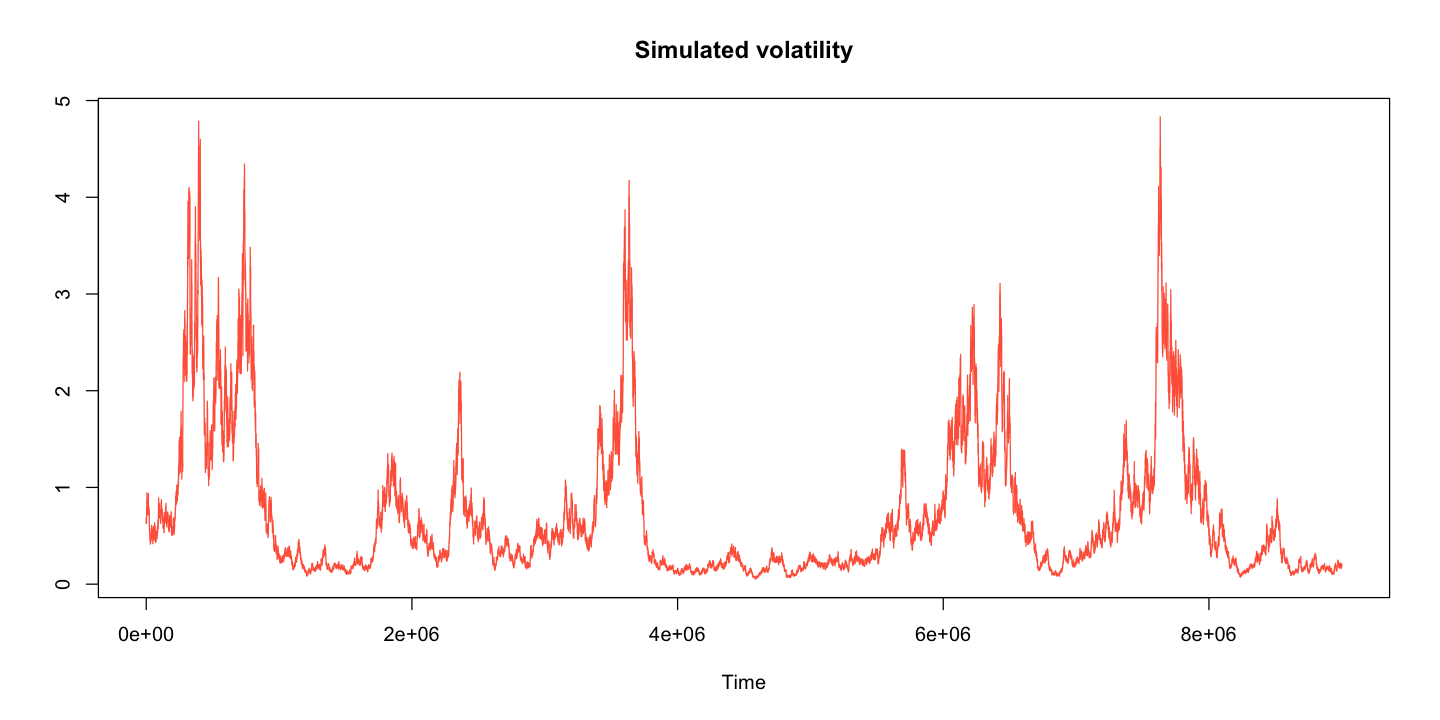

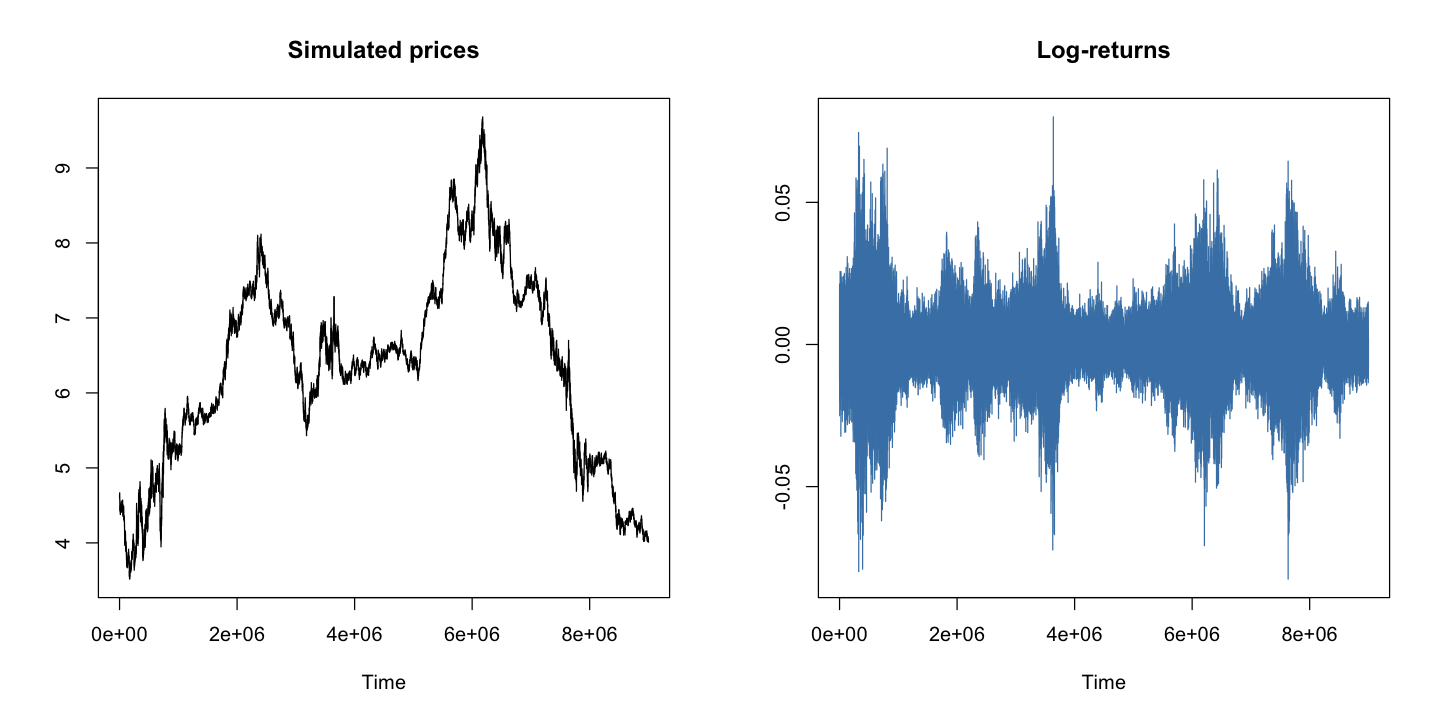

In [16]:
plot.ts(sigmasqr, ylab = NA, main = "Simulated volatility", col = 'tomato')

par(mfrow = c(1, 2))
plot.ts(p, ylab = NA, main = "Simulated prices")
plot.ts(r, ylab = NA, main = "Log-returns", col = 'steelblue')

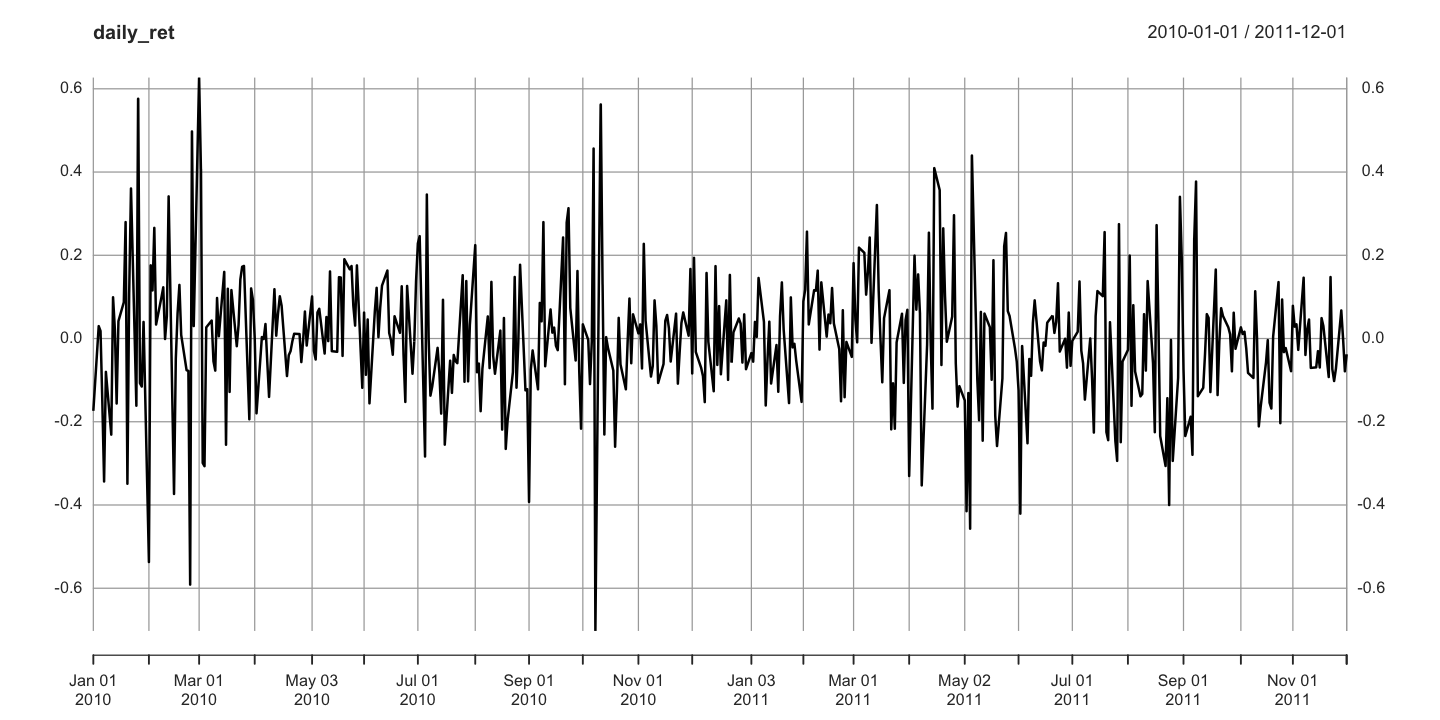

In [17]:
daily_ret<-to.daily(p)[,4]-to.daily(p)[,1]
plot(daily_ret)

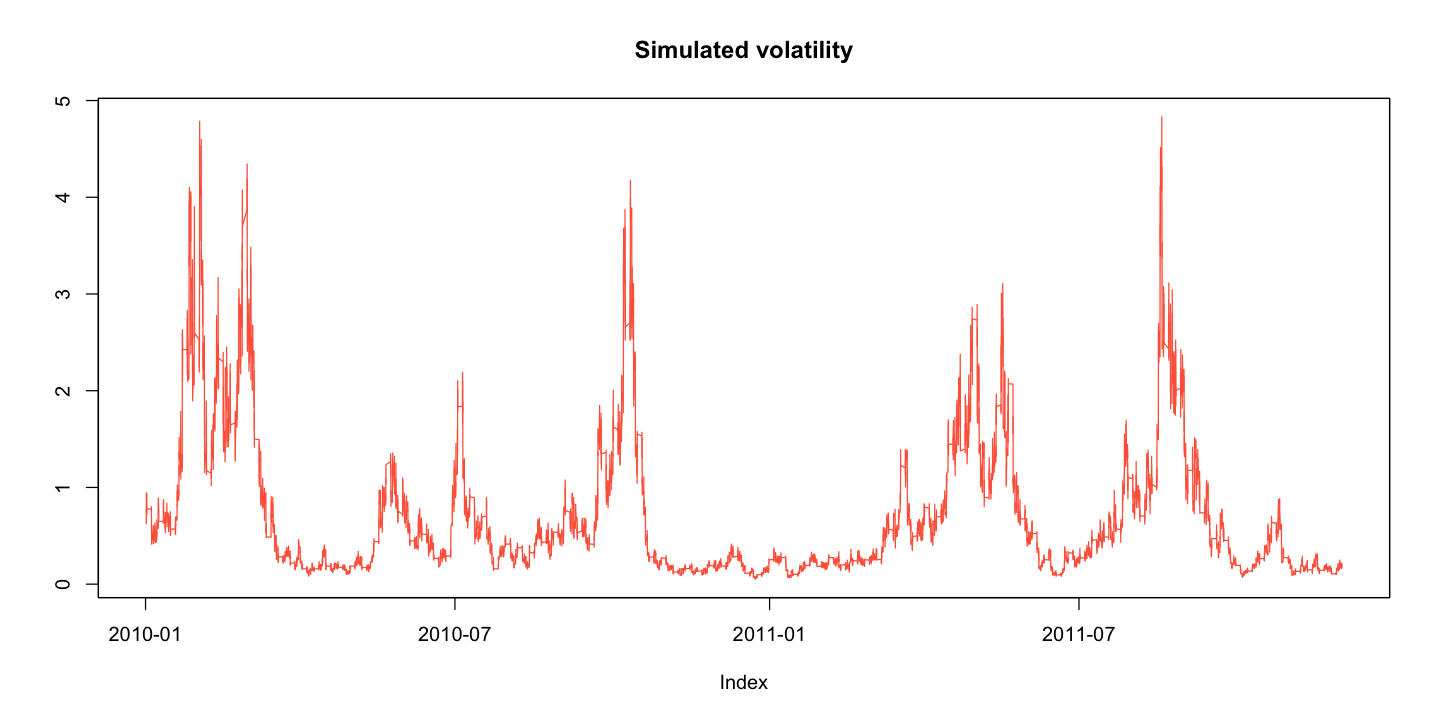

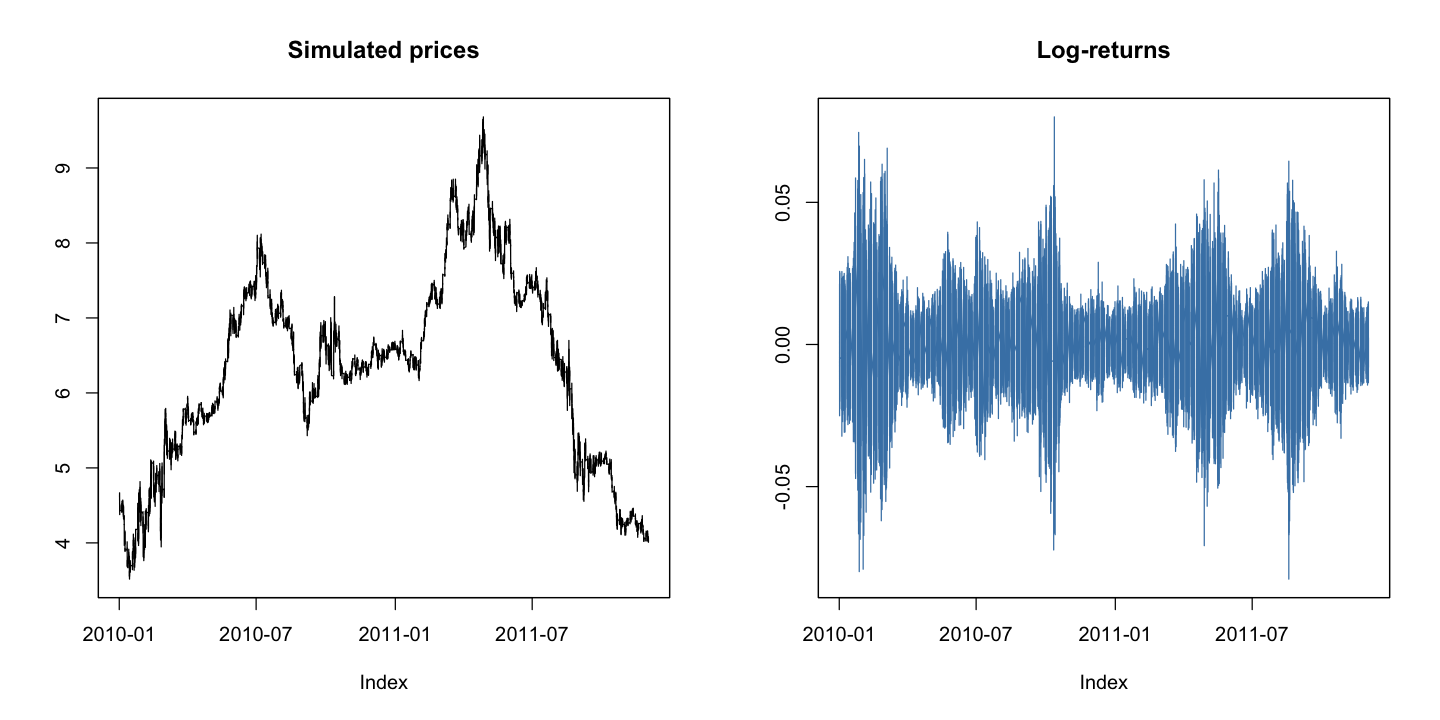

In [19]:
plot.zoo(sigmasqr, ylab = NA, main = "Simulated volatility", col = 'tomato')

par(mfrow = c(1, 2))
plot.zoo(p, ylab = NA, main = "Simulated prices")
plot.zoo(r, ylab = NA, main = "Log-returns", col = 'steelblue')

Add noise to the processes. Simulate jumps generated by the Poisson distribution, on average 2 jumps per day.

In [20]:
j <- rpois(TT * NN, 2 / NN)
sum(j)

[1] 1003

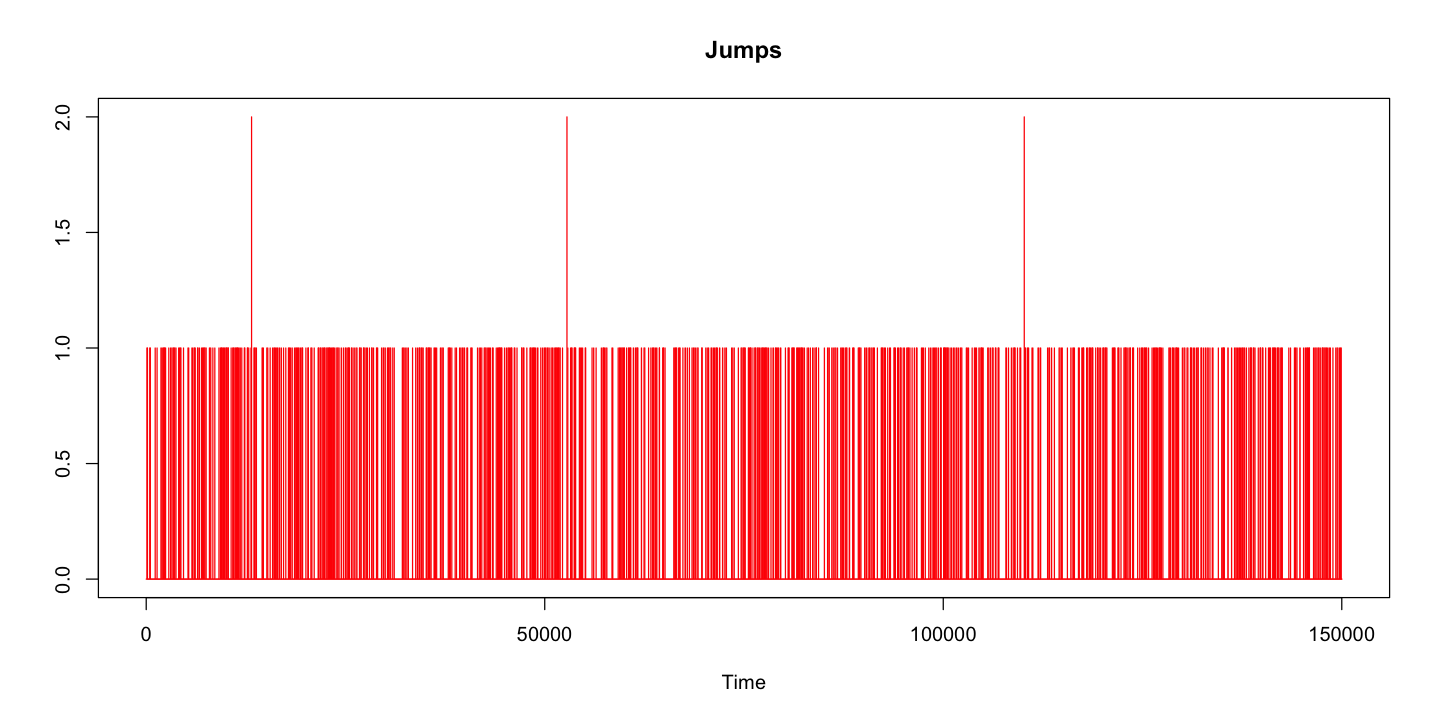

In [21]:
plot.ts(j, ylab = NA, main = 'Jumps', col = 'red')

Having average 2 jumps per day with 500 days results in approximately 1000 jumps. To make it bit more realistic, let's assume jumps have random magnitude

In [22]:
jumps <- rnorm(TT * NN) * j

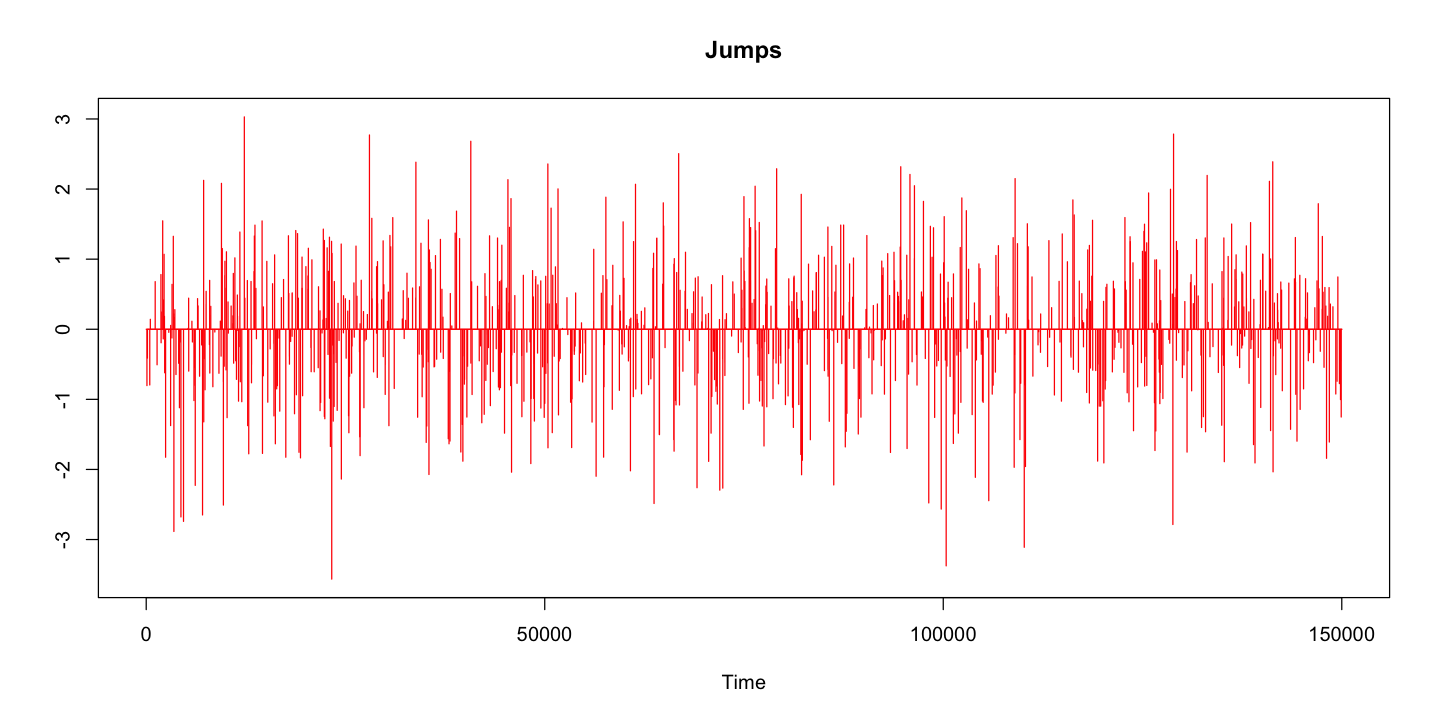

In [23]:
plot.ts(jumps, ylab = NA, main = 'Jumps', col = 'red')

Add jumps to the price process.

In [24]:
theta <- c(0.035, 0.636, 0.296)
TT <- 500
NN <- 300
dt <- 1 / NN

sigmasqr <- vector()
sigmasqr[1] <- theta[2]
W1 <- rnorm(TT * NN)
for (t in 2:(TT * NN)){
  sigmasqr[t] <- sigmasqr[t - 1] + theta[1] * (theta[2] - sigmasqr[t - 1]) * dt + 
    theta[3] * sigmasqr[t - 1] * sqrt(dt) * W1[t]
}
sigmasqr<-xts(sigmasqr,order.by = strptime(date_time, "%Y-%m-%d %H:%M"))

p <- vector()
p[1] <- log(100)
W2 <- rnorm(TT * NN, mean = 0, sd = 0.2)
for (t in 2:(TT * NN)){
  p[t] <- p[t-1] + sqrt(sigmasqr[t - 1]) * sqrt(dt) * W2[t]
}
p<-xts(p,order.by = strptime(date_time, "%Y-%m-%d %H:%M"))

J <- rnorm(TT * NN) * rpois(TT * NN, 100 / (TT * NN))

pj <- vector()
pj[1] <- p[1]
for (t in 2:(TT * NN)){
  pj[t] <- pj[t-1] + sqrt(sigmasqr[t - 1]) * sqrt(dt) * W2[t] + sqrt(dt) * J[t]
}
pj<-xts(pj,order.by = strptime(date_time, "%Y-%m-%d %H:%M"))

ret <- diff(p)
retj <- diff(pj)

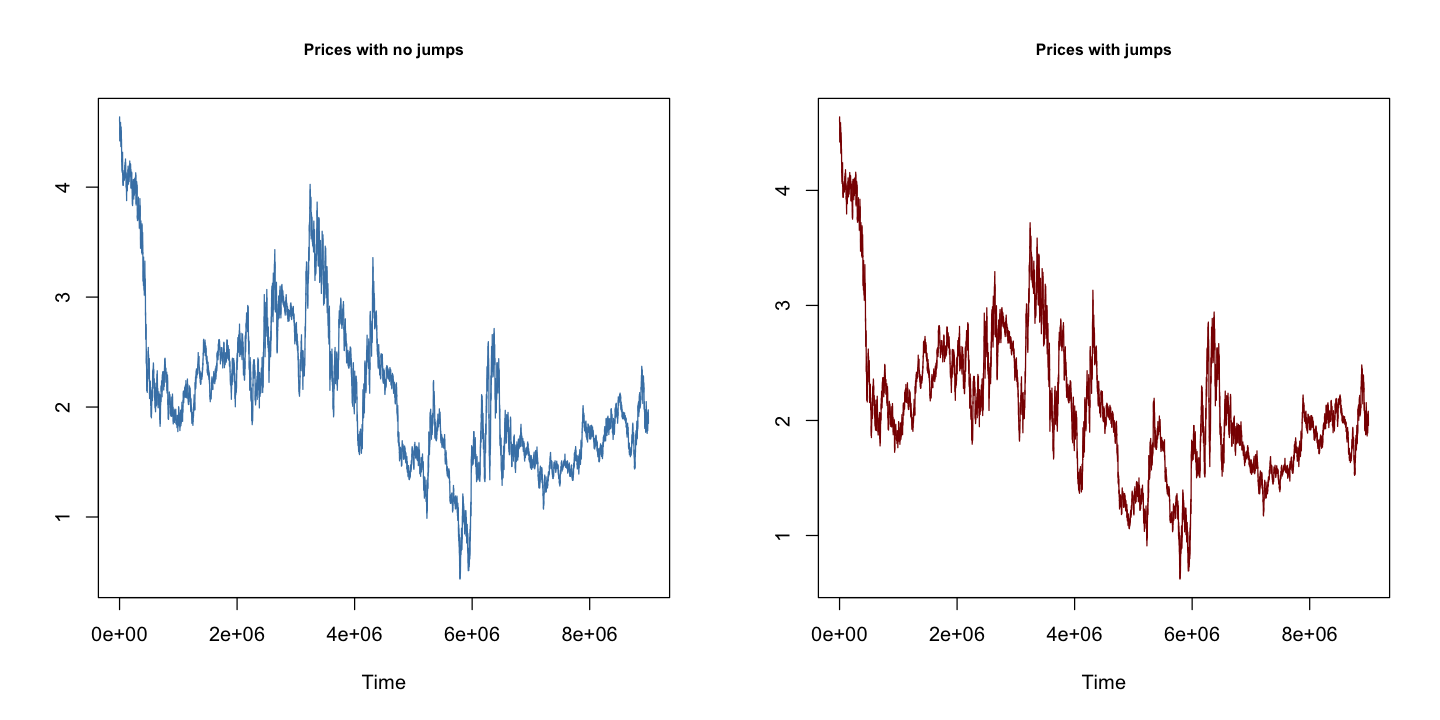

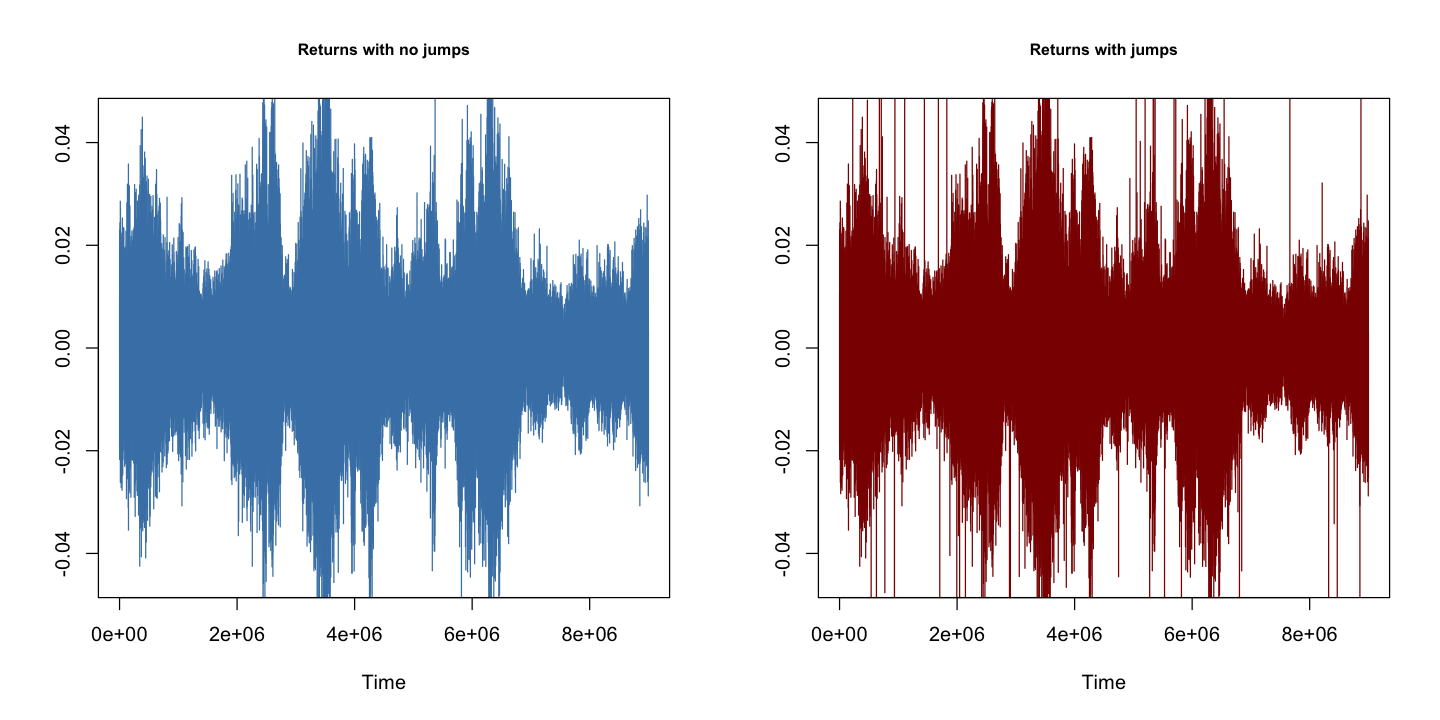

In [25]:
par(mfrow = c(1, 2))
plot.ts(p, ylab = NA, main = "Prices with no jumps", col = 'steelblue', cex.main = 0.8)
plot.ts(pj, ylab = NA, main = "Prices with jumps", col = 'red4', cex.main = 0.8)

plot.ts(ret, ylab = NA, main = "Returns with no jumps", col = 'steelblue', cex.main = 0.8, 
        ylim = c(-0.045, 0.045))
plot.ts(retj, ylab = NA, main = "Returns with jumps", col = 'red4', cex.main = 0.8, ylim = c(-0.045, 0.045))

The last plot clearly illustrates how much noise is added by presence of jumps.

### Can we use these high frequency intraday returns to compute daily variation?

Let's take 

$$RV_T=\sum_{i=1}^{NN} r_i^2$$

In [26]:
head(ret["20100105"])
tail(ret["20100105"])

                            [,1]
2010-01-05 09:30:00  0.006278462
2010-01-05 09:31:00 -0.011248250
2010-01-05 09:32:00 -0.006132623
2010-01-05 09:33:00  0.004831807
2010-01-05 09:34:00 -0.005173609
2010-01-05 09:35:00 -0.005979184

                             [,1]
2010-01-05 15:53:00  0.0047293434
2010-01-05 15:54:00  0.0098417172
2010-01-05 15:55:00 -0.0022020848
2010-01-05 15:56:00  0.0007256349
2010-01-05 15:58:00 -0.0045939426
2010-01-05 15:59:00  0.0015099589

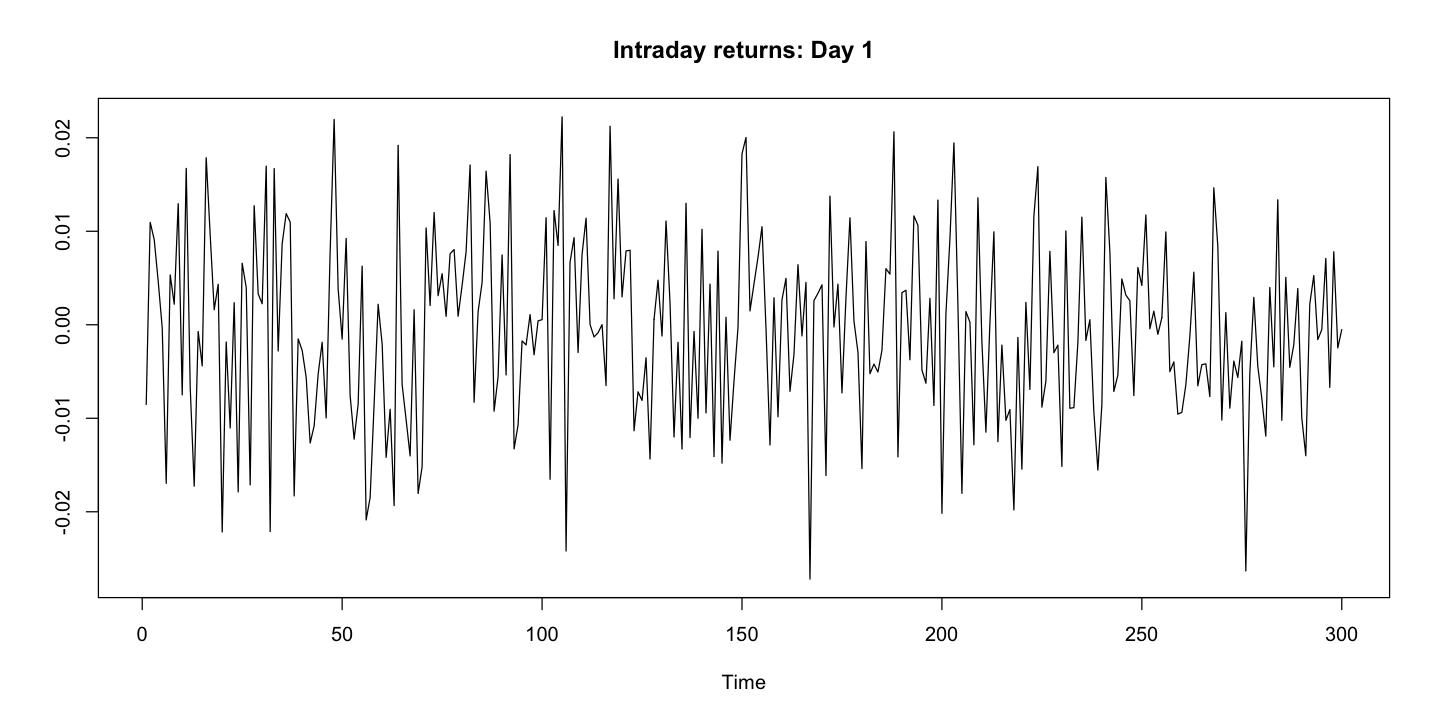

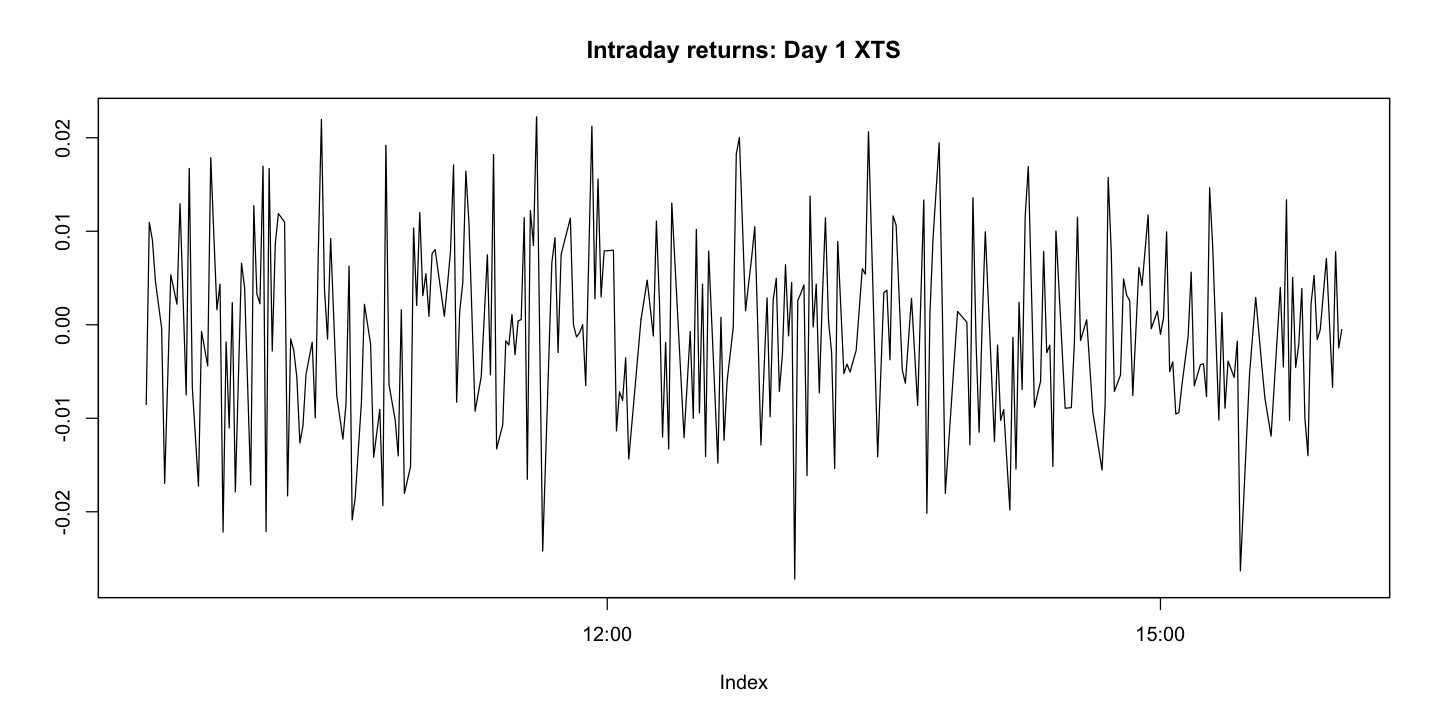

In [27]:
t=2
plot.ts(as.numeric(ret[((t - 1) * NN + 1):(t * NN)]), ylab = NA, main = 'Intraday returns: Day 1')
plot.zoo(ret[as.character(biz_days[t])],ylab = NA, main = 'Intraday returns: Day 1 XTS')

In [28]:
t=2
sum(ret[((t - 1) * NN + 1):(t * NN)]^2)
sqrt(sum(ret[((t - 1) * NN + 1):(t * NN)]^2))

[1] 0.0290991

[1] 0.1705846

Let's loop over all simulated days

In [29]:
RV <- unlist(lapply(lapply(1:TT, function (t){return(ret[((t - 1) * NN + 1):(t * NN)]^2)}),sum))

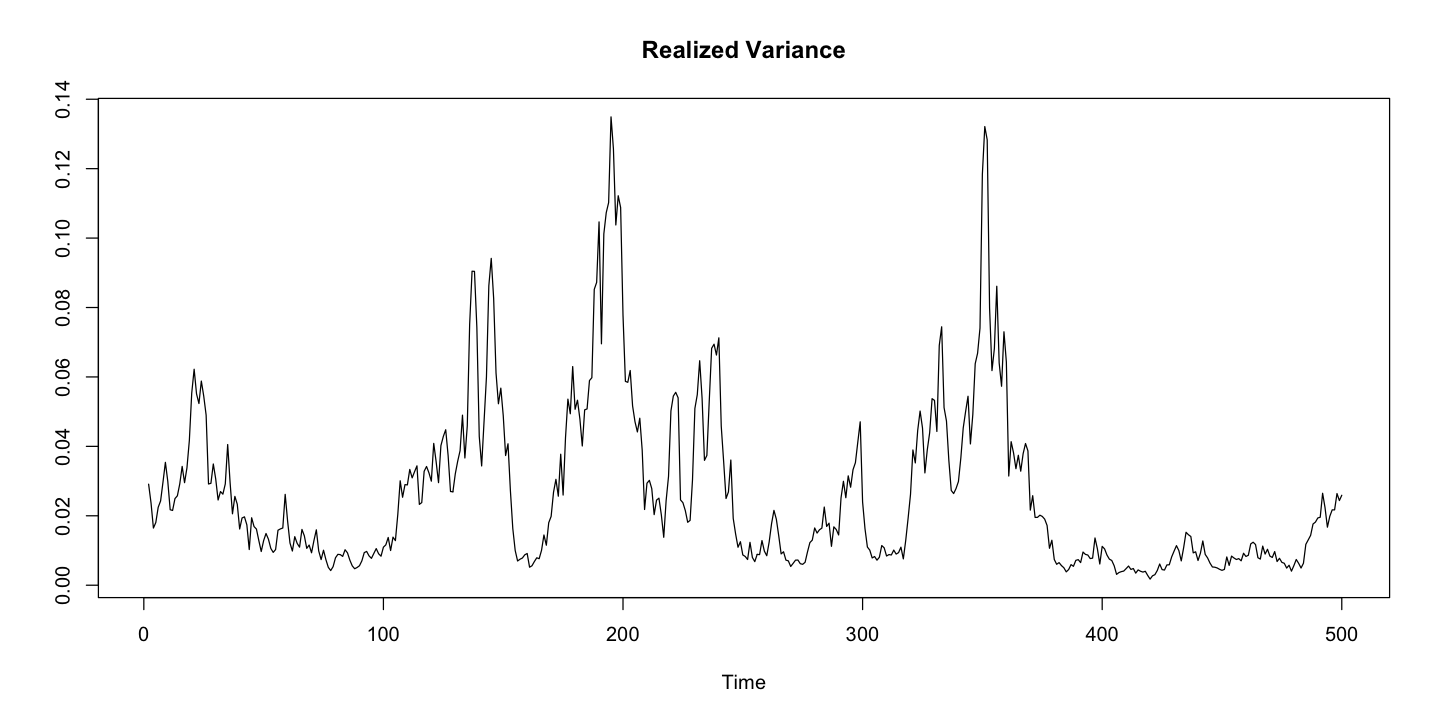

In [30]:
plot.ts(RV, ylab = NA, main = 'Realized Variance')

Comparison to approximation by $|r_t|$

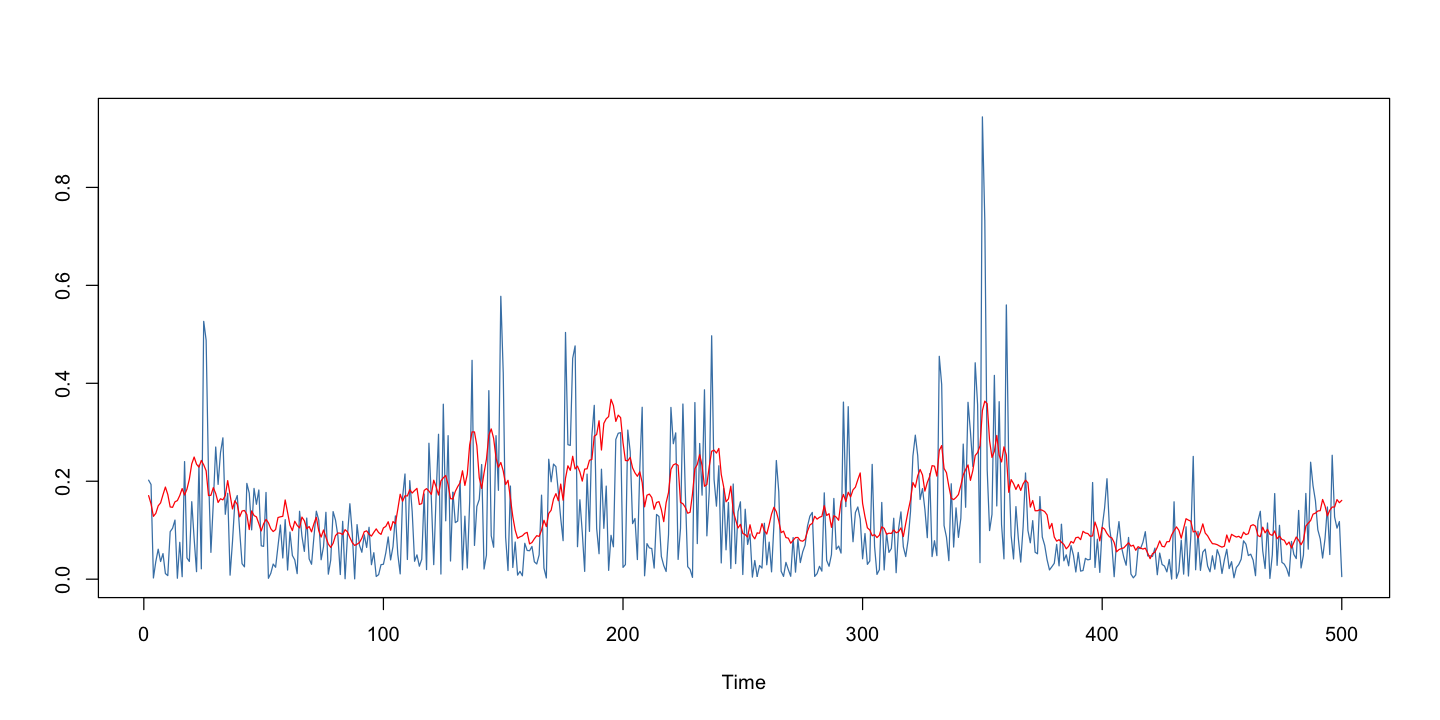

In [31]:
daily <- unlist(lapply(lapply(1:TT, function (t){return(ret[((t - 1) * NN + 1):(t * NN)])}), sum))

plot.ts(abs(daily), ylab = NA, col = 'steelblue')
lines(sqrt(RV), col = 'red')

Returns and its volatility computed using the intraday data

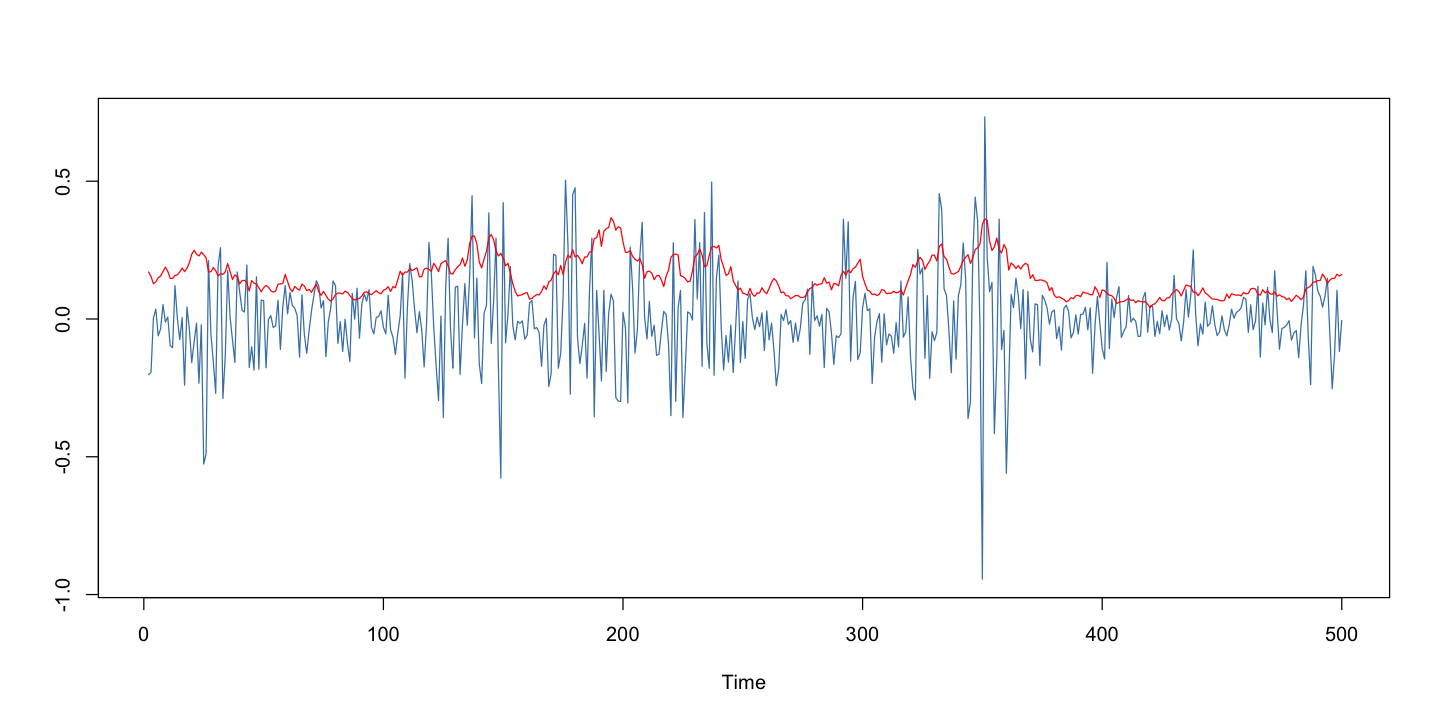

In [32]:
plot.ts(daily, ylab = NA, col = 'steelblue')
lines(sqrt(RV), col = 'red')

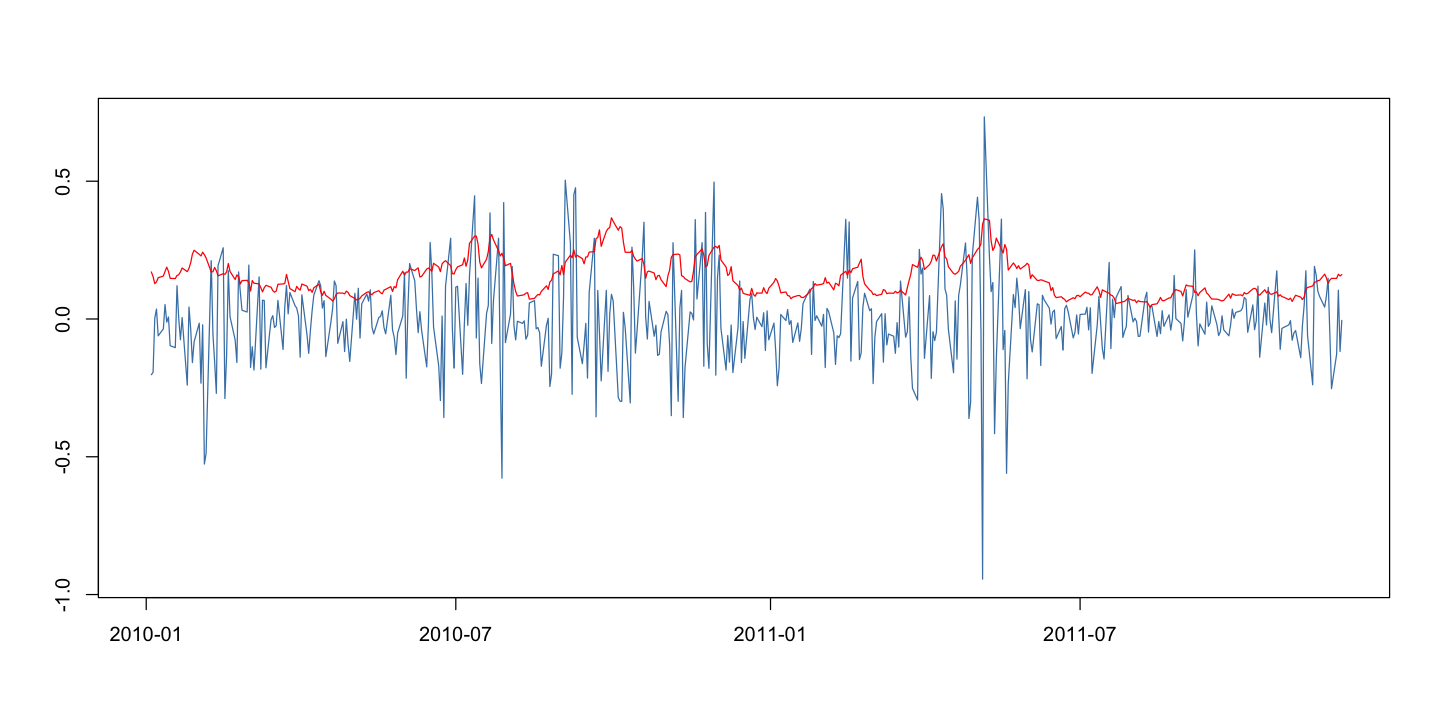

In [33]:
plot(x=biz_days[1:TT],y=daily,type="l",xlab = NA, ylab = NA, col = 'steelblue')
lines(x=biz_days[1:TT],y=sqrt(RV), col = 'red')